In [1]:
!pip install plotly
!pip install "ipywidgets>=7.6"
!pip install seaborn

In [2]:
import datetime as dt
import openml
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

pio.renderers.default = 'notebook_connected'

## EDIT WORDING

Electricity dataset for Victoria, Aus between 1 January 2015 and 6 October 2020. 
https://www.kaggle.com/datasets/aramacus/electricity-demand-in-victoria-australia/data

date : datetime, the date of the recording  
demand : float, a total daily electricity demand in MWh  
RRP : float, a recommended retail price in AUD per MWh  
demand_pos_RRP : float, a total daily demand at positive RRP in MWh  
RRP_positive : float, an averaged positive RRP, weighted by the corresponding intraday demand in AUD per MWh  
demand_neg_RRP : float, an total daily demand at negative RRP in MWh  
RRP_negative : float, an average negative RRP, weighted by the corresponding intraday demand in AUD per MWh  
frac_at_neg_RRP : float, a fraction of the day when the demand was traded at negative RRP  
min_temperature : float, minimum temperature during the day in Celsius  
max_temperature : float, maximum temperature during the day in Celsius  
solar_exposure : float, total daily sunlight energy in MJ/m^2  
rainfall : float, daily rainfall in mm  
school_day : boolean, if students were at school on that day  
holiday : boolean, if the day was a state or national holiday  

In [3]:

filepath ='../data/raw/complete_dataset.csv'

df_elec = pd.read_csv(filepath, parse_dates = ['date'])
df_elec = df_elec.set_index('date')
df_elec.head()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
date,,,,,,,,,,,,,
2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N


## Cleaning Data

In [4]:
# Check for missing dates in the range 1 January 2015 to 6 October 2020. 
full_range = pd.date_range(start=df_elec.index.min(), end=df_elec.index.max(), freq='D')
missing_dates = full_range.difference(df_elec.index)
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [5]:
# Checking for missing values
df_elec.isnull().sum()

demand             0
RRP                0
demand_pos_RRP     0
RRP_positive       0
demand_neg_RRP     0
RRP_negative       0
frac_at_neg_RRP    0
min_temperature    0
max_temperature    0
solar_exposure     1
rainfall           3
school_day         0
holiday            0
dtype: int64

In [6]:
# Because solar_exposure and rainfall vary continuously, we apply quadratic interpolation to fill the missing vals
df_elec['rainfall'] = df_elec['rainfall'].interpolate(method='polynomial', order=2)
df_elec['solar_exposure'] = df_elec['solar_exposure'].interpolate(method='polynomial', order=2)

In [7]:
df_elec.describe()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,120035.476503,76.079554,119252.305055,76.553847,783.171448,-2.686052,0.008547,11.582289,20.413200,14.744525,1.503320
std,13747.993761,130.246805,14818.631319,130.114184,3578.920686,19.485432,0.039963,4.313711,6.288693,7.943815,4.305425
min,85094.375000,-6.076028,41988.240000,13.568986,0.000000,-342.220000,0.000000,0.600000,9.000000,0.700000,-1.008289
25%,109963.650000,38.707040,109246.250000,39.117361,0.000000,0.000000,0.000000,8.500000,15.525000,8.200000,0.000000
50%,119585.912500,66.596738,119148.082500,66.869058,0.000000,0.000000,0.000000,11.300000,19.100000,12.750000,0.000000
75%,130436.006250,95.075012,130119.477500,95.130181,0.000000,0.000000,0.000000,14.600000,23.900000,20.700000,0.800000
max,170653.840000,4549.645105,170653.840000,4549.645105,57597.595000,0.000000,0.625000,28.000000,43.500000,33.300000,54.600000


## Creating Features

### Creating Date Features

In [8]:
# Convert cols school_day and holiday to booleans
for col in ['school_day', 'holiday']:
    df_elec[col] = df_elec[col].map(lambda x: True if x=='Y' else False)

# Extract the day of the week
df_elec['day'] = df_elec.index.strftime('%a')

# Extract the month
df_elec['month'] = df_elec.index.strftime('%b')

# Extract weekend, indicating whether the date falls on the weekend
df_elec['weekend'] = (df_elec.index.weekday >= 5)

df_elec.head()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday,day,month,weekend
date,,,,,,,,,,,,,,,,
2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,False,True,Thu,Jan,False
2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,False,False,Fri,Jan,False
2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,False,False,Sat,Jan,True
2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,False,False,Sun,Jan,True
2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,False,False,Mon,Jan,False


In [9]:
# Get the Southern Hemispheric meteorological season
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Fall'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df_elec['season'] = df_elec.index.to_series().apply(get_season)

df_elec.head()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday,day,month,weekend,season
date,,,,,,,,,,,,,,,,,
2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,False,True,Thu,Jan,False,Summer
2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,False,False,Fri,Jan,False,Summer
2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,False,False,Sat,Jan,True,Summer
2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,False,False,Sun,Jan,True,Summer
2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,False,False,Mon,Jan,False,Summer


### Creating Feature for Hazelwood Power Station Closure
In March 2017, the Hazelwood Power Station was closed. Prior to its closure, it had been responsible for ~22% of Victoria's electricity.
The electricity unit shut down took place between March 27 and March 29. 

In [10]:
closure = pd.Timestamp('2017-03-30')
df_elec['hazelwood_closed'] = (df_elec.index >= closure)

### Creating Features for Lack of Energy Events

In [11]:
energy_events = [
    (pd.Timestamp('2019-01-23'), pd.Timestamp('2019-01-25')), # Actual Lack of Reserve (LOR) level 3 in VIC
    (pd.Timestamp('2020-01-30'), pd.Timestamp('2020-02-01')), # Victoria and South Australia Separation Event
]

df_elec['energy_event'] = False

for start, end in energy_events:
    df_elec['energy_event'] |= df_elec.index.to_series().between(start, end)

df_elec.head()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday,day,month,weekend,season,hazelwood_closed,energy_event
date,,,,,,,,,,,,,,,,,,,
2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,False,True,Thu,Jan,False,Summer,False,False
2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,False,False,Fri,Jan,False,Summer,False,False
2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,False,False,Sat,Jan,True,Summer,False,False
2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,False,False,Sun,Jan,True,Summer,False,False
2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,False,False,Mon,Jan,False,Summer,False,False


### Creating Features for COV-19

In [12]:
# Melbourne lockdown dates taken from https://www.publish.csiro.au/ma/pdf/MA22002
mel_lockdowns = [
    (pd.Timestamp('2020-03-31'), pd.Timestamp('2020-05-13')),
    (pd.Timestamp('2020-07-09'), pd.Timestamp('2020-10-28')),
]

# Because the end of the 2nd Melbourne lockdown postdates the end of the dataset, we restrict the lockdown dates to coincide with the end of the dataset
last_date = df_elec.index.max()
for i, (start_date, end_date) in enumerate(mel_lockdowns):
    if last_date < end_date:
        end_date = last_date
        mel_lockdowns[i] = (start_date, last_date)
    
df_elec['mel_lockdown'] = False

for start, end in mel_lockdowns:
    df_elec['mel_lockdown'] |= df_elec.index.to_series().between(start, end)

df_elec.head()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday,day,month,weekend,season,hazelwood_closed,energy_event,mel_lockdown
date,,,,,,,,,,,,,,,,,,,,
2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,False,True,Thu,Jan,False,Summer,False,False,False
2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,False,False,Fri,Jan,False,Summer,False,False,False
2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,False,False,Sat,Jan,True,Summer,False,False,False
2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,False,False,Sun,Jan,True,Summer,False,False,False
2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,False,False,Mon,Jan,False,Summer,False,False,False


In [13]:
print(mel_lockdowns)

[(Timestamp('2020-03-31 00:00:00'), Timestamp('2020-05-13 00:00:00')), (Timestamp('2020-07-09 00:00:00'), Timestamp('2020-10-06 00:00:00'))]


## EDA

### Plot of Electricity Demand Over Time

In [14]:
# Get the date ranges for each season over the time interval
df_elec['season_change'] = (df_elec['season'] != df_elec['season'].shift()).cumsum()
season_ranges = df_elec.reset_index(drop=False).groupby('season_change').agg(
    season=('season', 'first'),
    start_date=('date', 'first'),
    end_date=('date', 'last')
)
season_ranges = [(row.season, row.start_date, row.end_date) for row in season_ranges.itertuples()]

season_colors = {
    'Summer': 'LightSalmon',
    'Autumn': 'LightGoldenRodYellow',
    'Winter': 'LightSkyBlue',
    'Spring': 'LightGreen'
}

In [15]:
fig = go.Figure()

# Add trace for daily electricity demand
fig.add_trace(go.Scatter(
    x=df_elec.index,
    y=df_elec['demand'],
    name='Daily Electricity Demand (in MWh)',
    mode='lines',
    hovertemplate='<b>Date:</b> %{x}<br><b>Demand:</b> %{y} MWh<extra></extra>',
    showlegend=False
))

# Add shaded boxes to denote seasons
shapes = []
for season, start_date, end_date in season_ranges:
    shapes.append(dict(
        type='rect',
        xref='x',
        yref='paper',
        x0=start_date,
        x1=end_date,
        y0=0,
        y1=1,
        fillcolor=season_colors.get(season, 'LightGray'),
        opacity=0.3,
        layer='below',
        line_width=0,
    ))
    
# Add dummy traces to make legend for the season boxes
for season, color in season_colors.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=10, color=color),
        name=season,
        showlegend=True
    ))

# Update layout
fig.update_layout(
    shapes = shapes,
    title='Electricity Demand in Victoria, AU Over Time',
    xaxis_title='Date',
    yaxis_title='Daily Electricity Demand (MWh)',
    legend_title='Season',
    template='plotly'
)


fig.show()

In [16]:
fig = go.Figure()

# Add trace for daily electricity demand
fig.add_trace(go.Scatter(
    x=df_elec.index,
    y=df_elec['demand'],
    name='Daily Electricity Demand (in MWh)',
    mode='lines',
    hovertemplate='<b>Date:</b> %{x}<br><b>Demand:</b> %{y} MWh<extra></extra>',
    showlegend=False
))

# Add orange rectangles to denote COVID lockdowns
rectangles = []
for start_date, end_date in mel_lockdowns:
    rectangles.append(dict(
        type='rect',
        xref='x',
        yref='paper',
        x0=pd.to_datetime(start_date),
        x1=pd.to_datetime(end_date),
        y0=0,
        y1=1,
        fillcolor='orange',
        opacity=0.3,
        layer='below',
        line_width=0,
    ))
    
# Add dummy trace for lockdowns to show in legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='orange'),
    name='COVID Lockdown',
    showlegend=True
))

# Add lime rectangles to denote lack of energy events
for start_date, end_date in energy_events:
    rectangles.append(dict(
        type='rect',
        xref='x',
        yref='paper',
        x0=pd.to_datetime(start_date),
        x1=pd.to_datetime(end_date),
        y0=0,
        y1=1,
        fillcolor='lime',
        opacity=0.3,
        layer='below',
        line=dict(color='limegreen', width=3)
    ))
    
# Add dummy trace for lack of energy events to show in legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='limegreen'),
    name='Lack of Energy Event',
    showlegend=True
))

# Add red line to denote Hazelwood plant closure
fig.add_vline(
    x=pd.to_datetime(closure), 
    line_width=2, 
    line_dash='dash', 
    line_color='red'
)

# Add dummy trace for Hazelwood closure to show in legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(dash='dash', color='red'),
    name='Hazelwood Plant Closure',
    showlegend=True
))

# Update layout
fig.update_layout(
    shapes = [*fig.layout.shapes, *rectangles],
    title='Electricity Demand in Victoria, AU Over Time',
    xaxis_title='Date',
    yaxis_title='Daily Electricity Demand (MWh)',
    template='plotly'
)


fig.show()

### Plots of RRP Over Time

In [17]:
fig = go.Figure()

# Add trace for daily electricity demand
fig.add_trace(go.Scatter(
    x=df_elec.index,
    y=df_elec['RRP'],
    mode='lines',
    hovertemplate='<b>Date:</b> %{x}<br><b>RRP:</b> %{y} AUD/MWh<extra></extra>',
    showlegend=False
))

# Add shaded boxes to denote seasons
shapes = []
for season, start_date, end_date in season_ranges:
    shapes.append(dict(
        type='rect',
        xref='x',
        yref='paper',
        x0=start_date,
        x1=end_date,
        y0=0,
        y1=1,
        fillcolor=season_colors.get(season, 'LightGray'),
        opacity=0.3,
        layer='below',
        line_width=0,
    ))
    
# Add dummy traces to make legend for the season boxes
for season, color in season_colors.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=10, color=color),
        name=season,
        showlegend=True
    ))

# Update layout
fig.update_layout(
    shapes = shapes,
    title='Recommended Retail Price of Electricity in Victoria, AU Over Time',
    xaxis_title='Date',
    yaxis_title='Recommended Retail Price (in AUP/MWh)',
    legend_title='Season',
    template='plotly'
)

fig.show()

In [18]:
fig = go.Figure()

# Add trace for daily electricity demand
fig.add_trace(go.Scatter(
    x=df_elec.index,
    y=df_elec['RRP'],
    mode='lines',
    hovertemplate='<b>Date:</b> %{x}<br><b>RRP:</b> %{y} AUD/MWh<extra></extra>',
    showlegend=False
))

# Add orange rectangles to denote COVID lockdowns
rectangles = []
for start_date, end_date in mel_lockdowns:
    rectangles.append(dict(
        type='rect',
        xref='x',
        yref='paper',
        x0=start_date,
        x1=end_date,
        y0=0,
        y1=1,
        fillcolor='orange',
        opacity=0.3,
        layer='below',
        line_width=0,
    ))
    
# Add dummy trace for lockdowns to show in legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='orange'),
    name='COVID Lockdown',
    showlegend=True
))

# Add lime rectangles to denote lack of energy events
for start_date, end_date in energy_events:
    rectangles.append(dict(
        type='rect',
        xref='x',
        yref='paper',
        x0=start_date,
        x1=end_date,
        y0=0,
        y1=1,
        fillcolor='lime',
        opacity=0.5,
        layer='below',
        line=dict(color='limegreen', width=3)
    ))
    
# Add dummy trace for lack of energy events to show in legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='limegreen'),
    name='Lack of Energy Event',
    showlegend=True
))

# Add red line to denote Hazelwood plant closure
fig.add_vline(
    x=closure, 
    line_width=2, 
    line_dash='dash', 
    line_color='red'
)

# Add dummy trace for Hazelwood closure to show in legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(dash='dash', color='red'),
    name='Hazelwood Plant Closure',
    showlegend=True
))

# Update layout
fig.update_layout(
    shapes = [*fig.layout.shapes, *rectangles],
    title='Recommended Retail Price of Electricity in Victoria, AU Over Time',
    xaxis_title='Date',
    yaxis_title='Recommended Retail Price (in AUP/MWh)',
    legend_title='Season',
    template='plotly'
)

fig.show()

### Heatmaps

In [ ]:
fig = go.Figure()

days = ['Thur', 'Fri', 'Sat', 'Sun']

for day in days:
    fig.add_trace(go.Violin(x=df['day'][df['day'] == day],
                            y=df['total_bill'][df['day'] == day],
                            name=day,
                            box_visible=True,
                            meanline_visible=True))

fig.show()

<Axes: xlabel='month', ylabel='demand'>

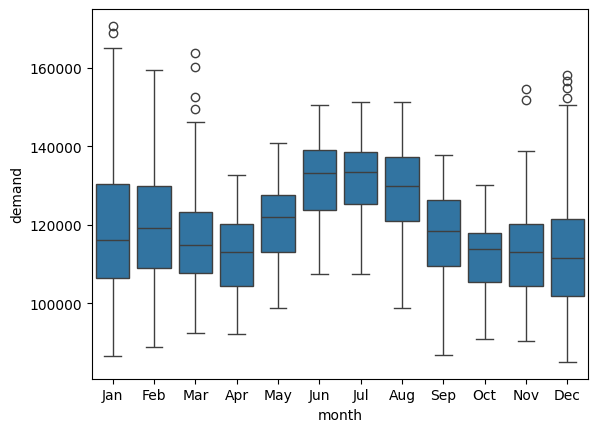

In [19]:
sns.boxplot(x='month', y='demand', data=df_elec)
